In [1]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import bootstrap
from copy import deepcopy
import json as json

In [98]:
proteins = ['a1-arb1d1_rhoTIA'] 
proteins_plotnames = {'a1-arb1d1_rhoTIA':r'$\alpha_{1B}$-AR-B1D1·$\rho$TIA'}
colors = {'af2chi':"#009E74", 'HSP':"#56B4E9",'MD':"#D55C00",'af2chi_prior':"green"}

In [3]:
blocksize = 100

In [4]:
def save_json(dictionary, outfile):
    with open(outfile, "w") as f:
        json.dump(dictionary, f)

In [5]:
def calc_methyl_S2_axis(traj, CC_atoms):
    methyl_S2_axis = {}

    for residue in traj.top.residues:
        residue = str(residue)
        #restype=residue[:3]
        #resnum=i+1 #int(residue[3:])

        resnum = int(''.join(filter(lambda x: x.isdigit(), residue)))
        resname = str(''.join(filter(lambda x: x.isalpha(), residue)))

        if 'HIS' in resname:
            resname = 'HIS'

        if resname not in CC_atoms:
            continue

        resatoms = traj.top.select(f'residue {resnum}{resname}')

        #print(resatoms, resname, resnum, residue)

        res_traj = traj.atom_slice(resatoms)

        res_S2_axis = []
        
        for i in range(len(CC_atoms[resname])):
            
            #Slice out relevant C atoms and get xyz coords
            C1 = CC_atoms[resname][i][0]
            C2 = CC_atoms[resname][i][1]
            atoms_CC = res_traj.top.select(f'name {C1} or name {C2}')
            atoms_CC_slice = res_traj.atom_slice(atoms_CC)
            CC_coords = atoms_CC_slice.xyz
            
            # Forward model from this paper: https://pubs.acs.org/doi/10.1021/ja0396955 (see start of SI methods)

            #Get xyz component of CC bond vector
            diff_CC = np.array([CC_coords[i][1]-CC_coords[i][0] for i in range(len(CC_coords))])
                        
            #Get CC bond vector length
            r_CC = np.array([np.linalg.norm(CC_coords[i][1]-CC_coords[i][0],axis=0) for i in range(len(CC_coords))])
            r_CC_avg = np.average(r_CC)
            
            xx_avg_sq = np.square(np.average(np.square(diff_CC[..., 0])))
            yy_avg_sq = np.square(np.average(np.square(diff_CC[..., 1])))
            zz_avg_sq = np.square(np.average(np.square(diff_CC[..., 2])))
            xy_avg_sq = np.square(np.average(diff_CC[..., 0]*diff_CC[..., 1]))
            xz_avg_sq = np.square(np.average(diff_CC[..., 0]*diff_CC[..., 2]))
            yz_avg_sq = np.square(np.average(diff_CC[..., 1]*diff_CC[..., 2]))

            S2_axis = (3/(2*r_CC_avg**4))*(xx_avg_sq + yy_avg_sq + zz_avg_sq + 2*xy_avg_sq + 2*xz_avg_sq + 2*yz_avg_sq) - 0.5
            
            res_S2_axis.append(S2_axis)
            
        methyl_S2_axis[residue] = res_S2_axis
    return methyl_S2_axis

def calc_methyl_S2_axis_blocks(traj, CC_atoms, blocksize):

    methyl_S2_axis = {}
    methyl_S2_axis_std = {}

    for residue in traj.top.residues:
        residue = str(residue)
        #restype=residue[:3]
        #resnum=i+1 #int(residue[3:])

        resnum = int(''.join(filter(lambda x: x.isdigit(), residue)))
        resname = str(''.join(filter(lambda x: x.isalpha(), residue)))

        if 'HIS' in resname:
            resname = 'HIS'

        if resname not in CC_atoms:
            continue

        resatoms = traj.top.select(f'residue {resnum}{resname}')

        #print(resatoms, resname, resnum, residue)

        res_traj = traj.atom_slice(resatoms)
        
        #Make a list of blocks of the trajectory with block size blocksize
        #res_traj_blocks = [res_traj[i:i+blocksize] for i in range(0, len(res_traj), blocksize)]
        res_traj_blocks = [res_traj[i:i+blocksize] for i in range(0, len(res_traj) - (len(res_traj) % blocksize), blocksize)]

        print(f'Nr res traj blocks: {len(res_traj_blocks)}')
        
        #Loop over the methyl types of this residue
        res_S2_axis = []
        res_S2_axis_std = []
        for i in range(len(CC_atoms[resname])):
            
            #Loop over blocks and calculate S2_axis for each block and average over all blocks
            res_S2_axis_vs_blocks = []
            for res_traj_block in res_traj_blocks:
                
                #Make sure block is of correct size
                assert len(res_traj_block) == blocksize

                #Slice out relevant C atoms and get xyz coords
                C1 = CC_atoms[resname][i][0]
                C2 = CC_atoms[resname][i][1]
                atoms_CC = res_traj_block.top.select(f'name {C1} or name {C2}')
                atoms_CC_slice = res_traj_block.atom_slice(atoms_CC)
                CC_coords = atoms_CC_slice.xyz
                
                # Forward model from this paper: https://pubs.acs.org/doi/10.1021/ja0396955 (see start of SI methods)

                #Get xyz component of CC bond vector
                diff_CC = np.array([CC_coords[i][1]-CC_coords[i][0] for i in range(len(CC_coords))])
                            
                #Get CC bond vector length
                r_CC = np.array([np.linalg.norm(CC_coords[i][1]-CC_coords[i][0],axis=0) for i in range(len(CC_coords))])
                r_CC_avg = np.average(r_CC)
                
                xx_avg_sq = np.square(np.average(np.square(diff_CC[..., 0])))
                yy_avg_sq = np.square(np.average(np.square(diff_CC[..., 1])))
                zz_avg_sq = np.square(np.average(np.square(diff_CC[..., 2])))
                xy_avg_sq = np.square(np.average(diff_CC[..., 0]*diff_CC[..., 1]))
                xz_avg_sq = np.square(np.average(diff_CC[..., 0]*diff_CC[..., 2]))
                yz_avg_sq = np.square(np.average(diff_CC[..., 1]*diff_CC[..., 2]))

                S2_axis = (3/(2*r_CC_avg**4))*(xx_avg_sq + yy_avg_sq + zz_avg_sq + 2*xy_avg_sq + 2*xz_avg_sq + 2*yz_avg_sq) - 0.5
                res_S2_axis_vs_blocks.append(S2_axis)
            
            #Average over blocks and append to list
            res_S2_axis.append(np.average(res_S2_axis_vs_blocks))
            res_S2_axis_std.append(np.std(res_S2_axis_vs_blocks))
                
        methyl_S2_axis[residue] = res_S2_axis
        methyl_S2_axis_std[residue] = res_S2_axis_std

    return methyl_S2_axis, methyl_S2_axis_std

def convert(obj):
    if isinstance(obj, dict):
        return {k: convert(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert(i) for i in obj]
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.integer):
        return int(obj)
    return obj

In [6]:
with open(f'../data/S2_axis_expt/expt_dummymodel.json', 'r') as openfile:
    json_object = json.load(openfile)
dummy_avgs = json_object['dummy_avgs']
dummy_errs = json_object['dummy_errs']

In [9]:
sidechain_ensemble_backkone_dir = f'../data/af2chi_data/af2chi_runs_S2proteins/s2_backbone_ensembles/bioemu/A_LBP_H/frame_0_clean.pdb'


In [18]:
af2chi_renumbering={}

<>:181: SyntaxWarning: invalid escape sequence '\c'
<>:183: SyntaxWarning: invalid escape sequence '\c'
<>:184: SyntaxWarning: invalid escape sequence '\c'
<>:185: SyntaxWarning: invalid escape sequence '\c'
<>:186: SyntaxWarning: invalid escape sequence '\c'
<>:211: SyntaxWarning: invalid escape sequence '\c'
<>:181: SyntaxWarning: invalid escape sequence '\c'
<>:183: SyntaxWarning: invalid escape sequence '\c'
<>:184: SyntaxWarning: invalid escape sequence '\c'
<>:185: SyntaxWarning: invalid escape sequence '\c'
<>:186: SyntaxWarning: invalid escape sequence '\c'
<>:211: SyntaxWarning: invalid escape sequence '\c'
/var/folders/8w/2dqxrgsd4vj00wv819dcz51w0000gn/T/ipykernel_43125/3983755020.py:181: SyntaxWarning: invalid escape sequence '\c'
  plt.errorbar(methyl_S2_axis_expt, methyl_S2_axis_af2chi_of3, xerr=methyl_S2_axis_expterr, fmt='o', c=colors['HSP'], markeredgecolor='black', ecolor='black', label=f'AF2$\chi$_isolate {pearson_af2chi_isolate:.2f}±{pearson_err_af2chi_isolate:.2f}')

{'ILE12': [np.float32(0.8368436)], 'ILE16': [np.float32(0.79426575)], 'ILE26': [np.float32(0.79263747)], 'ILE30': [np.float32(0.8586916)], 'ILE34': [np.float32(0.7438251)], 'ILE37': [np.float32(0.78054595)], 'ILE54': [np.float32(0.7353599)], 'ILE90': [np.float32(0.67597866)], 'ILE103': [np.float32(0.22397244)], 'ILE109': [np.float32(0.7585089)], 'ILE111': [np.float32(0.7748505)], 'ILE115': [np.float32(0.7897353)], 'ILE133': [np.float32(0.6276156)], 'ILE146': [np.float32(0.6733726)], 'ILE148': [np.float32(0.7592597)], 'ILE184': [np.float32(0.84782386)], 'ILE189': [np.float32(0.8049185)], 'ILE198': [np.float32(0.740718)], 'ILE233': [np.float32(0.79354835)], 'ILE239': [np.float32(0.85471773)], 'ILE247': [np.float32(0.68686247)], 'ILE281': [np.float32(0.661314)], 'ILE282': [np.float32(0.82508326)], 'ILE313': [np.float32(0.82612216)], 'ILE343': [np.float32(0.70674276)], 'ILE376': [np.float32(0.7099911)], 'ILE393': [np.float32(0.79337585)], 'ILE409': [np.float32(0.7500318)], 'ILE435': [np.fl

/var/folders/8w/2dqxrgsd4vj00wv819dcz51w0000gn/T/ipykernel_43125/3983755020.py:151: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return pearsonr(x,y)[0]
/Users/bqm193/miniconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:365: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)
/var/folders/8w/2dqxrgsd4vj00wv819dcz51w0000gn/T/ipykernel_43125/3983755020.py:174: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_dummy = pearsonr(methyl_S2_axis_expt, methyl_S2_axis_dummy)[0]


0.18492073336231016 0.35800260380064564
0.34947474536786055 0.18073052245955296
0.31515404415158915 0.30173197202305285
0.34947474536786055 0.18073052245955296
0.31515404415158915 0.30173197202305285
nan nan


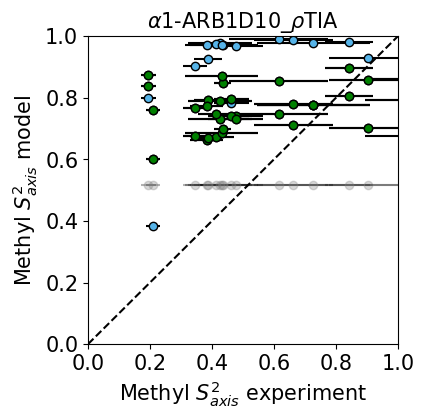

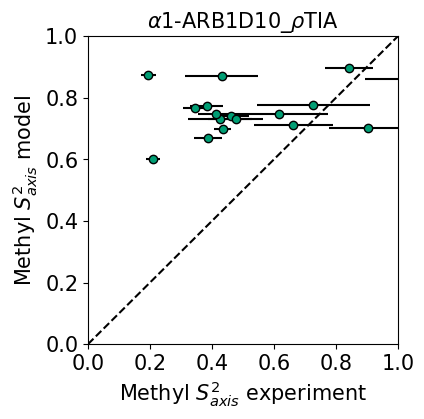

In [62]:
pearson_vs_model_vs_protein = {}
S2_axis_vs_model_vs_protein = {}
for protein in proteins:

    sidechain_ensemble_of3_dir = f'../data/gen_models_data/of3/a1_arb1d1/a1_arb1d1_of3_pred_H_nocys/'
    sidechain_ensemble_isolate_dir = f'../data/af2chi_data/af2chi_runs_S2proteins/{protein}/posterior/a1-arb1d1_H_noCys/'
    sidechain_ensemble_complex_dir = f'../data/af2chi_data/af2chi_runs_S2proteins/{protein}/posterior/a1-arb1d1_rhoTIA_H_noCys/'
    sidechain_ensemble_prior_isolate_dir = f'../data/af2chi_data/af2chi_runs_S2proteins/{protein}/posterior/a1-arb1d1_H_noCys/'
    sidechain_ensemble_prior_complex_dir = f'../data/af2chi_data/af2chi_runs_S2proteins/{protein}/posterior/a1-arb1d1_rhoTIA_H_noCys/'

    for frame_idx in range(50):
        #print(frame_idx)
        frame = md.load(f'{sidechain_ensemble_of3_dir}/frame_{frame_idx}_clean.pdb', top=f'{sidechain_ensemble_of3_dir}/frame_{frame_idx}_clean.pdb')
        frame.time = frame_idx
        if frame_idx==0:
            ensemble_af2chi_of3=frame 
        else:
            ensemble_af2chi_of3 = ensemble_af2chi_of3.join(frame)
    
    for frame_idx in range(50):
        #print(frame_idx)
        frame = md.load(f'{sidechain_ensemble_isolate_dir}/frame_{frame_idx}_clean.pdb', top=f'{sidechain_ensemble_isolate_dir}/frame_{frame_idx}_clean.pdb')
        frame.time = frame_idx
        if frame_idx==0:
            ensemble_af2chi_isolate=frame 
        else:
            ensemble_af2chi_isolate = ensemble_af2chi_isolate.join(frame)

    for frame_idx in range(50):
        #print(frame_idx)
        frame = md.load(f'{sidechain_ensemble_complex_dir}/frame_{frame_idx}_clean.pdb', top=f'{sidechain_ensemble_complex_dir}/frame_{frame_idx}_clean.pdb')
        frame.time = frame_idx
        if frame_idx==0:
            ensemble_af2chi_complex=frame 
        else:
            ensemble_af2chi_complex = ensemble_af2chi_complex.join(frame)

    for frame_idx in range(50):
        #print(frame_idx)
        frame = md.load(f'{sidechain_ensemble_prior_isolate_dir}/frame_{frame_idx}_clean.pdb', top=f'{sidechain_ensemble_prior_isolate_dir}/frame_{frame_idx}_clean.pdb')
        frame.time = frame_idx
        if frame_idx==0:
            ensemble_af2chi_prior_isolate=frame 
        else:
            ensemble_af2chi_prior_isolate = ensemble_af2chi_prior_isolate.join(frame)

    for frame_idx in range(50):
        #print(frame_idx)
        frame = md.load(f'{sidechain_ensemble_prior_complex_dir}/frame_{frame_idx}_clean.pdb', top=f'{sidechain_ensemble_prior_complex_dir}/frame_{frame_idx}_clean.pdb')
        frame.time = frame_idx
        if frame_idx==0:
            ensemble_af2chi_prior_complex=frame 
        else:
            ensemble_af2chi_prior_complex = ensemble_af2chi_prior_complex.join(frame)

    #Iteratively get average coordinates and superpose to them
    ensemble_af2chi_of3 = ensemble_af2chi_of3.superpose(ensemble_af2chi_of3, frame=0, atom_indices=ensemble_af2chi_of3.top.select('backbone'))

    ensemble_af2chi_isolate = ensemble_af2chi_isolate.superpose(ensemble_af2chi_isolate, frame=0, atom_indices=ensemble_af2chi_isolate.top.select('backbone'))
    ensemble_af2chi_complex = ensemble_af2chi_complex.superpose(ensemble_af2chi_complex, frame=0, atom_indices=ensemble_af2chi_complex.top.select('backbone'))

    ensemble_af2chi_prior_isolate = ensemble_af2chi_prior_isolate.superpose(ensemble_af2chi_prior_isolate, frame=0, atom_indices=ensemble_af2chi_prior_isolate.top.select('backbone'))
    ensemble_af2chi_prior_complex = ensemble_af2chi_prior_complex.superpose(ensemble_af2chi_prior_complex, frame=0, atom_indices=ensemble_af2chi_prior_complex.top.select('backbone'))
    

    for i in range(20):
        avg_frame_af2chi_of3 = deepcopy(ensemble_af2chi_of3[0])
        avg_frame_af2chi_of3.xyz = np.average(ensemble_af2chi_of3.xyz, axis=0)
        
        avg_frame_af2chi_isolate = deepcopy(ensemble_af2chi_isolate[0])
        avg_frame_af2chi_isolate.xyz = np.average(ensemble_af2chi_isolate.xyz, axis=0)
        avg_frame_af2chi_complex = deepcopy(ensemble_af2chi_complex[0])
        avg_frame_af2chi_complex.xyz = np.average(ensemble_af2chi_complex.xyz, axis=0)

        avg_frame_af2chi_prior_isolate = deepcopy(ensemble_af2chi_prior_isolate[0])
        avg_frame_af2chi_prior_isolate.xyz = np.average(ensemble_af2chi_prior_isolate.xyz, axis=0)
        avg_frame_af2chi_prior_complex = deepcopy(ensemble_af2chi_prior_complex[0])
        avg_frame_af2chi_prior_complex.xyz = np.average(ensemble_af2chi_prior_complex.xyz, axis=0)

        ensemble_af2chi_of3 = ensemble_af2chi_of3.superpose(avg_frame_af2chi_of3, atom_indices=ensemble_af2chi_of3.top.select('backbone'))
        ensemble_af2chi_isolate = ensemble_af2chi_isolate.superpose(avg_frame_af2chi_isolate, atom_indices=ensemble_af2chi_isolate.top.select('backbone'))
        ensemble_af2chi_complex = ensemble_af2chi_complex.superpose(avg_frame_af2chi_complex, atom_indices=ensemble_af2chi_complex.top.select('backbone'))
        ensemble_af2chi_prior_isolate = ensemble_af2chi_prior_isolate.superpose(avg_frame_af2chi_prior_isolate, atom_indices=ensemble_af2chi_isolate.top.select('backbone'))
        ensemble_af2chi_prior_complex = ensemble_af2chi_prior_complex.superpose(avg_frame_af2chi_prior_complex, atom_indices=ensemble_af2chi_complex.top.select('backbone'))
    #print(charmm36m_traj)

    with open(f'../data/S2_axis_expt/{protein}.json', 'r') as openfile:
        json_object = json.load(openfile)
    protein_S2_axis_expt = json_object['data']
    CC_atoms = json_object['CC_atoms']     

    af2chi_methyl_S2_axis_of3 = calc_methyl_S2_axis(ensemble_af2chi_of3, CC_atoms)
    af2chi_methyl_S2_axis_isolate = calc_methyl_S2_axis(ensemble_af2chi_isolate, CC_atoms)
    af2chi_methyl_S2_axis_complex = calc_methyl_S2_axis(ensemble_af2chi_complex, CC_atoms)
    af2chi_methyl_S2_axis_prior_isolate = calc_methyl_S2_axis(ensemble_af2chi_prior_isolate, CC_atoms)
    af2chi_methyl_S2_axis_prior_complex = calc_methyl_S2_axis(ensemble_af2chi_prior_complex, CC_atoms)
    
    methyl_S2_axis_af2chi_of3 = []
    methyl_S2_axis_af2chi_isolate = []
    methyl_S2_axis_af2chi_complex = []
    methyl_S2_axis_af2chi_prior_isolate = []
    methyl_S2_axis_af2chi_prior_complex = []
    
    methyl_S2_axis_expt = []
    methyl_S2_axis_expterr = []
    methyl_S2_axis_dummy = []
    methyl_S2_axis_dummyerr = []

    print(af2chi_methyl_S2_axis_isolate)

    for res in protein_S2_axis_expt :
        print(res)
        for i,S2_axis in enumerate(protein_S2_axis_expt[res]):

            S2_axis_af2chi_of3 = af2chi_methyl_S2_axis_of3[res][i]
            S2_axis_af2chi_isolate = af2chi_methyl_S2_axis_isolate[res][i]
            S2_axis_af2chi_complex = af2chi_methyl_S2_axis_complex[res][i]
            S2_axis_af2chi_prior_isolate = af2chi_methyl_S2_axis_prior_isolate[res][i]
            S2_axis_af2chi_prior_complex = af2chi_methyl_S2_axis_prior_complex[res][i]
                
            S2_axis_expt = S2_axis[0]
            S2_axis_expterr = S2_axis[1]

            if S2_axis_expt != 'NaN':
                methyl_S2_axis_af2chi_of3.append(S2_axis_af2chi_of3)
                methyl_S2_axis_af2chi_isolate.append(S2_axis_af2chi_isolate)
                methyl_S2_axis_af2chi_complex.append(S2_axis_af2chi_complex)
                methyl_S2_axis_af2chi_prior_isolate.append(S2_axis_af2chi_prior_isolate)
                methyl_S2_axis_af2chi_prior_complex.append(S2_axis_af2chi_prior_complex)
                
                methyl_S2_axis_expt.append(S2_axis_expt)
                methyl_S2_axis_expterr.append(S2_axis_expterr)

                atoms = CC_atoms[res[:3]][i]
                methyl_S2_axis_dummy.append(dummy_avgs[f'{res[:3]}_{atoms[0]}_{atoms[1]}'])
                methyl_S2_axis_dummyerr.append(dummy_errs[f'{res[:3]}_{atoms[0]}_{atoms[1]}'])

    methyl_S2_axis_af2chi_of3 = np.array(methyl_S2_axis_af2chi_of3)
    methyl_S2_axis_af2chi_isolate = np.array(methyl_S2_axis_af2chi_isolate)
    methyl_S2_axis_af2chi_complex = np.array(methyl_S2_axis_af2chi_complex)
    methyl_S2_axis_af2chi_prior_isolate = np.array(methyl_S2_axis_af2chi_prior_isolate)
    methyl_S2_axis_af2chi_prior_complex = np.array(methyl_S2_axis_af2chi_prior_complex)
    
    methyl_S2_axis_expt = np.array(methyl_S2_axis_expt)
    methyl_S2_axis_expterr = np.array(methyl_S2_axis_expterr)
    methyl_S2_axis_dummy = np.array(methyl_S2_axis_dummy)
    methyl_S2_axis_dummyerr = np.array(methyl_S2_axis_dummyerr)

    assert  len(methyl_S2_axis_af2chi_isolate) == len(methyl_S2_axis_af2chi_complex) == len(methyl_S2_axis_expt) == len(methyl_S2_axis_expterr) 
    def pearsonoutput(x,y):
        return pearsonr(x,y)[0]
    bootstrap_result_af2chi_of3 = bootstrap((methyl_S2_axis_expt, methyl_S2_axis_af2chi_of3), pearsonoutput, vectorized=False, paired=True)    
    pearson_err_af2chi_of3 = bootstrap_result_af2chi_of3.standard_error
    
    bootstrap_result_af2chi_isolate = bootstrap((methyl_S2_axis_expt, methyl_S2_axis_af2chi_isolate), pearsonoutput, vectorized=False, paired=True)    
    pearson_err_af2chi_isolate = bootstrap_result_af2chi_isolate.standard_error
    bootstrap_result_af2chi_complex = bootstrap((methyl_S2_axis_expt, methyl_S2_axis_af2chi_complex), pearsonoutput, vectorized=False, paired=True)    
    pearson_err_af2chi_complex = bootstrap_result_af2chi_complex.standard_error

    bootstrap_result_af2chi_prior_isolate = bootstrap((methyl_S2_axis_expt, methyl_S2_axis_af2chi_prior_isolate), pearsonoutput, vectorized=False, paired=True)    
    pearson_err_af2chi_prior_isolate = bootstrap_result_af2chi_isolate.standard_error
    bootstrap_result_af2chi_prior_complex = bootstrap((methyl_S2_axis_expt, methyl_S2_axis_af2chi_prior_complex), pearsonoutput, vectorized=False, paired=True)    
    pearson_err_af2chi_prior_complex = bootstrap_result_af2chi_complex.standard_error
    
    bootstrap_result_dummy = bootstrap((methyl_S2_axis_expt, methyl_S2_axis_dummy), pearsonoutput, vectorized=False, paired=True)    
    pearson_err_dummy = bootstrap_result_dummy.standard_error

    pearson_af2chi_of3 = pearsonr(methyl_S2_axis_expt, methyl_S2_axis_af2chi_of3)[0]
    pearson_af2chi_isolate = pearsonr(methyl_S2_axis_expt, methyl_S2_axis_af2chi_isolate)[0]
    pearson_af2chi_complex = pearsonr(methyl_S2_axis_expt, methyl_S2_axis_af2chi_complex)[0]
    pearson_af2chi_prior_isolate = pearsonr(methyl_S2_axis_expt, methyl_S2_axis_af2chi_prior_isolate)[0]
    pearson_af2chi_prior_complex = pearsonr(methyl_S2_axis_expt, methyl_S2_axis_af2chi_prior_complex)[0]

    pearson_dummy = pearsonr(methyl_S2_axis_expt, methyl_S2_axis_dummy)[0]

    fig = plt.figure(figsize=(4,4))

    plt.title(proteins_plotnames[protein], fontsize=15)

    plt.plot([0,1], [0,1], '--', c='k')
    plt.errorbar(methyl_S2_axis_expt, methyl_S2_axis_af2chi_of3, xerr=methyl_S2_axis_expterr, fmt='o', c=colors['HSP'], markeredgecolor='black', ecolor='black', label=f'AF2$\chi$_isolate {pearson_af2chi_isolate:.2f}±{pearson_err_af2chi_isolate:.2f}')

    plt.errorbar(methyl_S2_axis_expt, methyl_S2_axis_af2chi_isolate, xerr=methyl_S2_axis_expterr, fmt='o', c=colors['af2chi'], markeredgecolor='black', ecolor='black', label=f'AF2$\chi$_isolate {pearson_af2chi_isolate:.2f}±{pearson_err_af2chi_isolate:.2f}')
    plt.errorbar(methyl_S2_axis_expt, methyl_S2_axis_af2chi_prior_isolate, xerr=methyl_S2_axis_expterr, fmt='o', c=colors['af2chi_prior'], markeredgecolor='black', ecolor='black', label=f'AF2$\chi$_isolate {pearson_af2chi_prior_isolate:.2f}±{pearson_err_af2chi_prior_isolate:.2f}')
    plt.errorbar(methyl_S2_axis_expt, methyl_S2_axis_af2chi_complex, xerr=methyl_S2_axis_expterr, fmt='o', c=colors['af2chi'], markeredgecolor='black', ecolor='black', label=f'AF2$\chi$_complex {pearson_af2chi_complex:.2f}±{pearson_err_af2chi_complex:.2f}')
    plt.errorbar(methyl_S2_axis_expt, methyl_S2_axis_af2chi_prior_complex, xerr=methyl_S2_axis_expterr, fmt='o', c=colors['af2chi_prior'], markeredgecolor='black', ecolor='black', label=f'AF2$\chi$_complex {pearson_af2chi_prior_complex:.2f}±{pearson_err_af2chi_prior_complex:.2f}')
    
    plt.errorbar(methyl_S2_axis_expt, methyl_S2_axis_dummy, xerr=methyl_S2_axis_expterr, fmt='o', c='gray', alpha=0.3, ecolor='black', label=f'Null model {pearson_dummy:.2f}±{pearson_err_dummy:.2f}')

    #plt.legend(fontsize=15, bbox_to_anchor=(1,1.3), ncol=3)

    plt.ylabel('Methyl $S^{2}_{axis}$ model', fontsize=15)
    plt.xlabel('Methyl $S^{2}_{axis}$ experiment', fontsize=15)

    plt.tick_params(axis='both', which='major', labelsize=15)

    plt.xticks(np.arange(0,1.1,0.2))
    plt.yticks(np.arange(0,1.1,0.2))

    plt.xlim(0, 1.0)
    plt.ylim(0, 1.0)

    plt.savefig(f'../figures/{protein}_S2_allmodels.pdf', bbox_inches='tight')

    fig = plt.figure(figsize=(4,4))

    plt.title(proteins_plotnames[protein], fontsize=15)

    plt.plot([0,1], [0,1], '--', c='k')

    plt.errorbar(methyl_S2_axis_expt, methyl_S2_axis_af2chi_complex, xerr=methyl_S2_axis_expterr, fmt='o', c=colors['af2chi'], markeredgecolor='black', ecolor='black', label=f'AF2$\chi$ {pearson_af2chi_complex:.2f}±{pearson_err_af2chi_complex:.2f}')

    #plt.legend(fontsize=15, bbox_to_anchor=(1,1.3), ncol=3)

    plt.ylabel('Methyl $S^{2}_{axis}$ model', fontsize=15)
    plt.xlabel('Methyl $S^{2}_{axis}$ experiment', fontsize=15)

    plt.tick_params(axis='both', which='major', labelsize=15)

    plt.xticks(np.arange(0,1.1,0.2))
    plt.yticks(np.arange(0,1.1,0.2))

    plt.xlim(0, 1.0)
    plt.ylim(0, 1.0)

    plt.savefig(f'../figures/{protein}_S2_af2chionly.pdf', bbox_inches='tight')

    print(pearson_af2chi_of3, pearson_err_af2chi_of3)
    print(pearson_af2chi_isolate, pearson_err_af2chi_isolate)
    print(pearson_af2chi_complex, pearson_err_af2chi_complex)
    print(pearson_af2chi_prior_isolate, pearson_err_af2chi_prior_isolate)
    print(pearson_af2chi_prior_complex, pearson_err_af2chi_prior_complex)

    print(pearson_dummy, pearson_err_dummy)

    S2_axis_vs_model = {}
    S2_axis_vs_model['af2chi_of3'] = list(methyl_S2_axis_af2chi_of3)
    S2_axis_vs_model['af2chi_isolate'] = list(methyl_S2_axis_af2chi_isolate)
    S2_axis_vs_model['af2chi_complex'] = list(methyl_S2_axis_af2chi_complex)
    S2_axis_vs_model['af2chi_prior_isolate'] = list(methyl_S2_axis_af2chi_prior_isolate)
    S2_axis_vs_model['af2chi_prior_complex'] = list(methyl_S2_axis_af2chi_prior_complex)
    
    S2_axis_vs_model['expt'] = list(methyl_S2_axis_expt)
    S2_axis_vs_model['expt_err'] = list(methyl_S2_axis_expterr)
    S2_axis_vs_model['dummy'] = list(methyl_S2_axis_dummy)
    S2_axis_vs_model['dummy_err'] = list(methyl_S2_axis_dummyerr)
    
    S2_axis_vs_model_vs_protein[protein] = S2_axis_vs_model

    pearson_vs_model = {}
    pearson_vs_model['af2chi_of3'] = pearson_af2chi_of3
    pearson_vs_model['af2chi_isolate'] = pearson_af2chi_isolate
    pearson_vs_model['af2chi_err_isolate'] = pearson_err_af2chi_isolate
    pearson_vs_model['af2chi_complex'] = pearson_af2chi_complex
    pearson_vs_model['af2chi_err_complex'] = pearson_err_af2chi_complex

    pearson_vs_model['af2chi_prior_isolate'] = pearson_af2chi_prior_isolate
    pearson_vs_model['af2chi_err_prior_isolate'] = pearson_err_af2chi_prior_isolate
    pearson_vs_model['af2chi_prior_complex'] = pearson_af2chi_prior_complex
    pearson_vs_model['af2chi_err_prior_complex'] = pearson_err_af2chi_prior_complex
    
    pearson_vs_model['dummy'] = pearson_dummy   
    pearson_vs_model['dummy_err'] = pearson_err_dummy

    pearson_vs_model_vs_protein[protein] = pearson_vs_model

save_json(convert(S2_axis_vs_model_vs_protein), '../data/S2_axis_expt/S2_models_membrane.json')
save_json(convert(pearson_vs_model_vs_protein), '../data/S2_axis_expt/pearson_models_expt_membrane.json')

# Plot correlations barplot

In [63]:
def load_json(file):
    with open(file, 'r') as f:
        loaded_json = json.load(f)
    return loaded_json

In [64]:
proteins_plotorder = ['a1-arb1d1_rhoTIA']

<>:9: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\m'
/var/folders/8w/2dqxrgsd4vj00wv819dcz51w0000gn/T/ipykernel_43125/2618589923.py:9: SyntaxWarning: invalid escape sequence '\c'
  plt.bar(positions[1], pearson_vs_model_vs_protein[protein]['af2chi_prior_isolate'],       yerr=pearson_vs_model_vs_protein[protein]['af2chi_err_prior_complex'], edgecolor='k', color=colors['af2chi_prior'],       width=width, label='AF2$\chi$ prior'       if label else '')
/var/folders/8w/2dqxrgsd4vj00wv819dcz51w0000gn/T/ipykernel_43125/2618589923.py:10: SyntaxWarning: invalid escape sequence '\c'
  plt.bar(positions[2], pearson_vs_model_vs_protein[protein]['af2chi_isolate'],             yerr=pearson_vs_model_vs_protein[protein]['af2chi_err_isolate'],       edgec

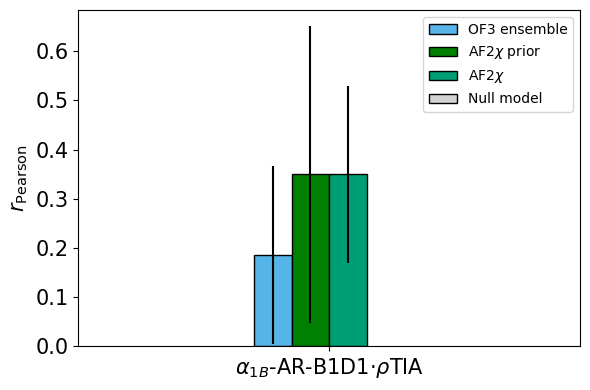

In [99]:
fig = plt.figure(figsize=(6,4))

width = 0.30
spacing = 1.4
positions = np.array([-0.45, -0.15,+0.15, +0.45])


plt.bar(positions[0], pearson_vs_model_vs_protein[protein]['af2chi_of3'],             yerr=pearson_vs_model_vs_protein[protein]['af2chi_err_isolate'],       edgecolor='k', color=colors['HSP'],             width=width, label='OF3 ensemble'             if label else '')
plt.bar(positions[1], pearson_vs_model_vs_protein[protein]['af2chi_prior_isolate'],       yerr=pearson_vs_model_vs_protein[protein]['af2chi_err_prior_complex'], edgecolor='k', color=colors['af2chi_prior'],       width=width, label='AF2$\chi$ prior'       if label else '')
plt.bar(positions[2], pearson_vs_model_vs_protein[protein]['af2chi_isolate'],             yerr=pearson_vs_model_vs_protein[protein]['af2chi_err_isolate'],       edgecolor='k', color=colors['af2chi'],             width=width, label='AF2$\chi$'             if label else '')
plt.bar(positions[3], pearson_vs_model_vs_protein[protein]['dummy'],              yerr=pearson_vs_model_vs_protein[protein]['dummy_err'],        edgecolor='k', color='lightgray',                  width=width, label='Null model'            if label else '')

plt.xlim(-2,2)
plt.ylabel('$r_\mathrm{Pearson}$', fontsize=15)
plt.yticks(fontsize=15)
plt.xticks(ticks=np.arange(len(proteins_plotorder)) * spacing,
           labels=[proteins_plotnames[protein] for protein in proteins_plotorder],
           rotation=00, fontsize=15)
plt.legend(ncols=1)
plt.tight_layout()
plt.savefig('../figures/alpha1-arb1d1_rhoTIA_baplot.pdf')